# CPSC 330 midterm

In this exam we'll be analyzing the [Rain in Australia](https://www.kaggle.com/jsphyg/weather-dataset-rattle-package) dataset from Kaggle. This exam consists of 14 **equally weighted** questions interspersed between parts of the analysis. The exam was printed directly from Jupyter; that is, all the output you see was generated by the code you see, with no "tampering" after-the-fact.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 16
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [3]:
pd.set_option('display.precision', 2)

The last line (above) tells pandas to print numbers to 2 decimal places (the default is 6 places). This should improve readability for you.

## Preliminaries

Load the data:

In [4]:
df = pd.read_csv('weatherAUS.csv', parse_dates=['Date'])

Code I added in to get rid of rows with NA targets

In [5]:
valid_rows = df["RainTomorrow"].notna()
print(df.shape[0])
df = df[valid_rows]
print(df.shape[0])

145460
142193


Split the data by date (you can assume this is a reasonable thing to do):

In [6]:
df_train = df.query('Date <= 20121231')
df_valid = df.query('20130101 <= Date <= 20151231')
df_test  = df.query('Date >= 20160101')

First, I call `df.describe()` to get a sense of some of the features:

In [ ]:
df.describe()

It's interesting to note that the max temperature was 48 degrees; that's very hot!

## Q1

What did I do wrong in the above line, and what should I have done instead? **Maximum 2 sentences.**

you used describe on the entire dataframe. you should only describe data in the train set when doing EDA (test data should be completely unseen!)


---------------

Next I create X and y. Note: the dataset documentation says to remove `RISK_MM`. I will also drop the `Date`.

In [8]:
target_column = 'RainTomorrow'
drop_columns = ['Date'] # RISK_MM not in updated dataset
X_train = df_train.drop(columns=[target_column] + drop_columns)
X_valid = df_valid.drop(columns=[target_column] + drop_columns)
X_test  = df_test.drop( columns=[target_column] + drop_columns)

In [9]:
y_train = df_train[target_column]
y_valid = df_valid[target_column]
y_test = df_test[target_column]

Start looking at the data:

In [10]:
X_train.shape

(65491, 21)

In [ ]:
X_train

In [12]:
numeric_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
categorical_features = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

Make sure all columns are accounted for:

In [13]:
all_features = numeric_features + categorical_features

In [14]:
assert set(X_train.columns) == set(all_features)

Next, I perform similar transformations to what you've seen in the course, using `SimpleImputer`, `StandardScaler`, and `OneHotEncoder`. 

In [15]:
imputers = [('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', SimpleImputer(strategy='most_frequent'), categorical_features)]

In [16]:
impute_transformer = ColumnTransformer(transformers=imputers)

In [17]:
impute_transformer.fit(X_train);

In [18]:
X_train_imp = pd.DataFrame(impute_transformer.transform(X_train), index=X_train.index, columns=all_features)
X_valid_imp = pd.DataFrame(impute_transformer.transform(X_valid), index=X_valid.index, columns=all_features)
X_test_imp  = pd.DataFrame(impute_transformer.transform(X_test),  index=X_test.index,  columns=all_features)

Below, we use `drop='first'` for all the columns except 'Location':

In [19]:
transformers=[
    ('scale', StandardScaler(), numeric_features),
    ('ohe1', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Location']),
    ('ohe2', OneHotEncoder(sparse_output=False, drop='first'), categorical_features[1:])]

In [20]:
preprocessor = ColumnTransformer(transformers=transformers)

In [21]:
preprocessor.fit(X_train_imp);

In [22]:
new_columns = numeric_features + list(preprocessor.named_transformers_['ohe1'].get_feature_names_out(['Location'])) + list(preprocessor.named_transformers_['ohe2'].get_feature_names_out(categorical_features[1:]))

In [23]:
X_train_transformed = pd.DataFrame(preprocessor.transform(X_train_imp), index=X_train_imp.index, columns=new_columns)
X_valid_transformed = pd.DataFrame(preprocessor.transform(X_valid_imp), index=X_valid_imp.index, columns=new_columns)
X_test_transformed  = pd.DataFrame(preprocessor.transform(X_test_imp),  index=X_test_imp.index,  columns=new_columns)

## Q2

The `RainToday` feature is binary: it only takes on the values "Yes" or "No". I used `OneHotEncoder` to one-hot encode this feature with `drop='first'`. What differences we would observe, if any, had we instead used `OrdinalEncoder` for `RainToday`? Briefly justify your answer. **Maximum 2 sentences.**

Ordinal Encoder would have encoded no as either 0 or 1, and yes as the other number.  one hot encoder creates two columns, one with 1s when no and 0s for yes, and vice versa. depending on which column was dropped with drop="first", either there will be no difference to ordinal encoder, or the encoding will be swapped (e.g. if ordinal encoder had a column that encoded 0 for no, 1 for yes, the ohe column could be 0 for yes, 1 for no)

---------------

Next, I'll use a `DummyClassifier` like the one you implemented in hw4:

In [24]:
y_train.isna().value_counts()

RainTomorrow
False    65491
Name: count, dtype: int64

In [25]:
dc = DummyClassifier(strategy='prior')
dc.fit(X_train_transformed, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [26]:
dc.score(X_train_transformed, y_train)

0.7669756149699959

In [27]:
dc.score(X_valid_transformed, y_valid)

0.7896625137990854

## Q3

Given the above, quantify the level of class imbalance in this dataset. Briefly justify your answer. **Maximum 2 sentences.**

about 0.77 of the classes are one of the classes. this is pretty noticeable, moderate to high class imbalance (i know because of the scores of dumym classifier, as strategy="prior" always predicts the most common class)


---------------

Next, we fit a `DecisionTreeClassifier` where the maximum depth of the tree is 2. We set `max_features=5` only because it makes the exam question more interesting, not because it's a good idea.

In [28]:
dt = DecisionTreeClassifier(max_depth=2, max_features=5, random_state=321)
dt.fit(X_train_transformed, y_train);

We then visualize the tree:

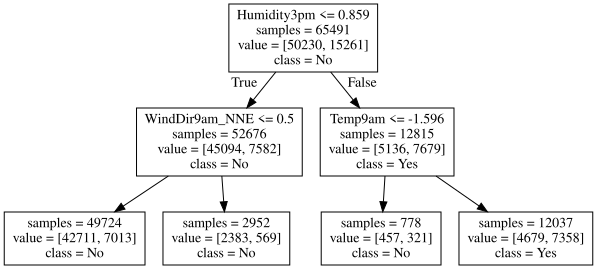

In [26]:
graphviz.Source(export_graphviz(dt, out_file=None, feature_names=new_columns,
                                class_names=dt.classes_, impurity=False))

Note: for some reason, the arrows are not labeled on the second level, but you can assume that the left side branch is always True and the right branch is always False. So, the 4 arrows in the second level should be  labelled True, False, True, False if reading from left to right.

Here is the first element of the validation set. First I print out (a subset of) the **transformed** numerical variables:

In [29]:
X_valid_transformed[numeric_features].iloc[:1,9:]

,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
1431,-1.79,-0.7,-0.88,0.19,0.16,0.89,1.71


And then I print out the **un-transformed** categorical features:

In [30]:
X_valid[categorical_features].iloc[:1]

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
1431,Albury,W,SE,W,No


## Q4

Describe the path of this example down the tree. Which of the four bottom nodes does it end up at: the 1st, 2nd, 3rd or 4th? **Maximum 3 sentences.**

2. humidity 3pm is less than 0.859, so go down true branch. winddir9am is not NNE, so go down false branch. so, we end up in the second node.


---------------

The following code grabs 4 numeric features - but I'm not telling you which ones.

In [31]:
np.random.seed(1) # set random state
some_numeric_features = np.random.permutation(numeric_features)[10:14]

In hw2, for the spotify dataset, you looked at histograms of various feature values split up by target class. The following code creates 4 such histograms, one for each of the 4 randomly chosen numeric features, using the training set.

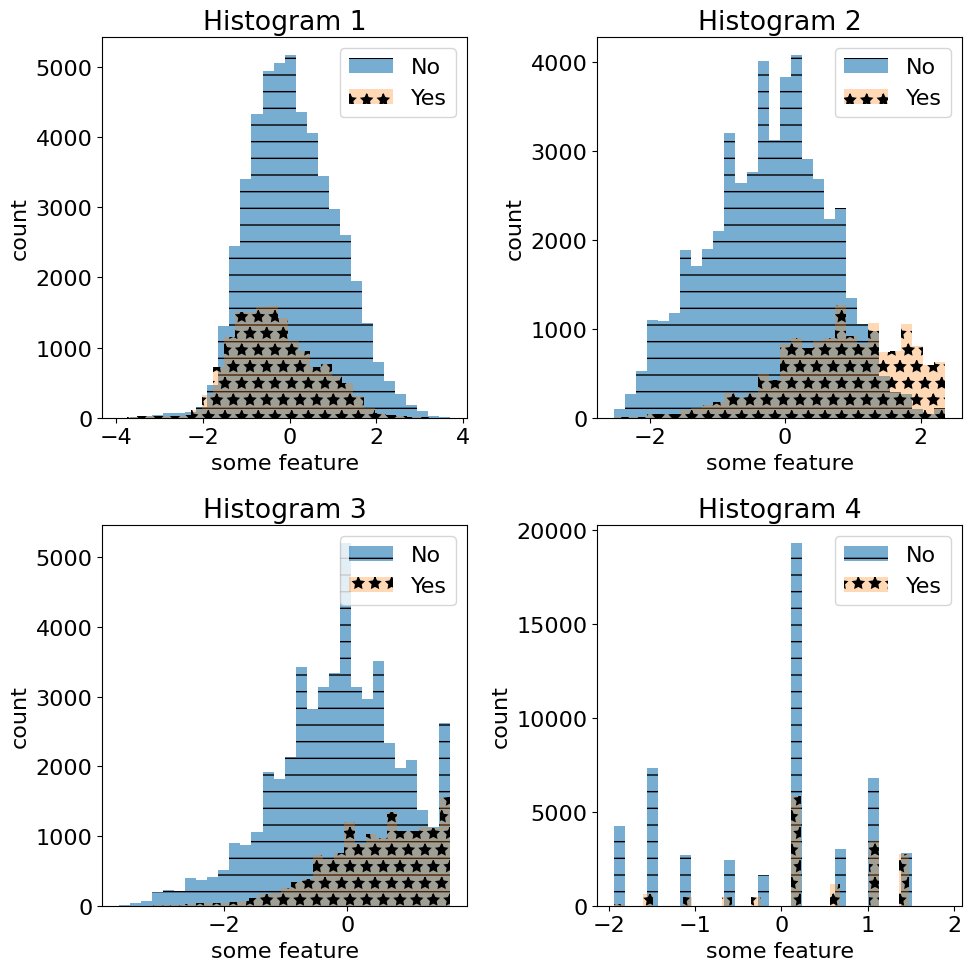

In [32]:
X_train_neg = X_train_transformed[y_train == "No"]
X_train_pos = X_train_transformed[y_train == "Yes"]

plt.figure(figsize=(10,10))
for i, feature in enumerate(some_numeric_features):

    plt.subplot(2,2,i+1)
    plt.hist(X_train_neg[feature], alpha=0.6, bins=30, label="No", hatch="-")
    plt.hist(X_train_pos[feature], alpha=0.3, bins=30, label="Yes", hatch="*")
    plt.legend(loc='upper right')
    plt.xlabel('some feature')
    plt.ylabel("count")
    plt.title(f"Histogram {i+1}")
plt.tight_layout();

## Q5

I haven't told you which feature is being used to generate each histogram. Based on the decision tree visualization above, which of the 4 histograms (Histogram 1, Histogram 2, Histogram 3, or Histogram 4) do you think corresponds to the feature `Humidity3pm`? Briefly justify your answer. **Maximum 3 sentences.**

Hint: `Humidity3pm <= 0.859` was chosen by `DecisionTreeClassifier` to be the very first split (i.e., it's at the top of the tree). This indicates that it's a useful split for separating the classes.

histogram 2 because of hint (useful separating classes, histogram 2 has greatest separation between yes and no)


---------------

Next, I'll fit a logistic regression:

In [33]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_transformed, y_train);

In [34]:
lr.score(X_train_transformed, y_train)

0.8465590691850788

In [35]:
lr.score(X_valid_transformed, y_valid)

0.853887399463807

## Q6

Given the above, would it make more sense to try increasing or decreasing the `C` hyperparameter? As a reminder, increasing `C` increases model complexity. Briefly justify your answer. **Maximum 2 sentences.**

increase C because underfit model because train and valid scores very similar (valid is in fact greater than train)


---------------

The following are some of the coefficients learned by `LogisticRegression` (only some of them are shown):

In [36]:
pd.DataFrame(data=lr.coef_[0], index=X_train_transformed.columns, columns=["Coefficient"])

,Coefficient
MinTemp,0.12
MaxTemp,-0.56
Rainfall,0.11
Evaporation,0.05
Sunshine,-0.33
...,...
WindDir3pm_SW,-0.05
WindDir3pm_W,0.03
WindDir3pm_WNW,0.16
WindDir3pm_WSW,-0.04


## Q7

You will notice that `Evaporation` has a positive coefficient. True or False: increasing the `Evaporation` value (and leaving all other features fixed) will increased the predicted probability that it will rain tomorrow (i.e., the positive class). Briefly justify your answer. **Maximum 2 sentences.**

In [37]:
lr.classes_

array(['No', 'Yes'], dtype=object)

True because as you can see in code block above, yes is positive class, and a positive coefficient means that as you increase that feature the positive class becomes more likely


---------------

## Q8

You will notice that `WindDir3pm_W`, which is a binary variable created by the `OneHotEncoder`, has a positive coefficient. True or False: an observation with `WindDir3pm` equal to 'W' will have a higher  predicted probability that it will rain tomorrow (i.e., the positive class) than an observation with `WindDir3pm` equal to any other value (leaving all other original features fixed). Briefly justify your answer. **Maximum 2 sentences.**

False. While it is true that having a 1 in the WindDir3pm_W category will increase the probabilty of RainTomorrow, a 1 in the WindDir3pm_WNW column will actually result in a higher increase in RainTomorrow probabilty (because there is a larger positive coefficient for WNW than N)

---------------

Next I will train a random forest on this dataset:

In [38]:
rf = RandomForestClassifier(random_state=123)
rf.fit(X_train_transformed, y_train);

Here's the confusion matrix based on the **training** set:

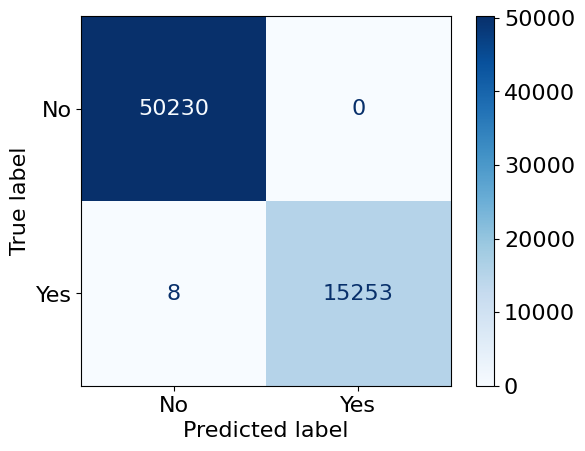

In [41]:
disp = ConfusionMatrixDisplay.from_estimator(rf, X_train_transformed, y_train,
                             display_labels=rf.classes_,
                             cmap=plt.cm.Blues, 
                             values_format = 'd');

## Q9

Suppose we re-ran the code but with `class_weight="balanced"`. In that case, would you expect the number in the **lower-left** box to increase or decrease? Briefly justify your answer. **Maximum 3 sentences.**

Hint: as a reminder, `class_weight="balanced"` increases the "weight" (or importance) of examples in the minority class.

Decrease. With class_weight="balanced", you pay more attention to the minority class (yes), so the model will make more YES predictions. the boxes on the right column should increase in value. 


---------------

Below is the confusion matrix for the **validation** set.

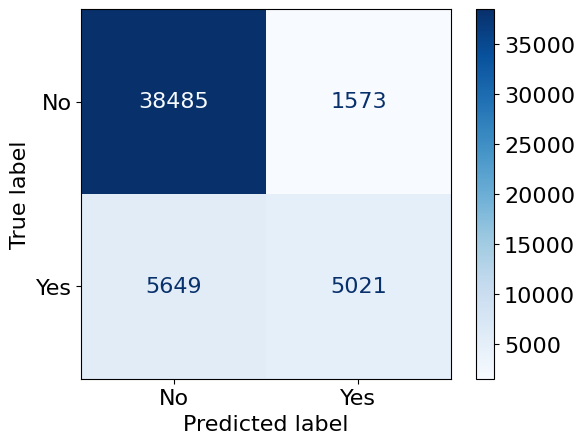

In [42]:
disp = ConfusionMatrixDisplay.from_estimator(rf, X_valid_transformed, y_valid,
                             display_labels=rf.classes_,
                             cmap=plt.cm.Blues, 
                             values_format = 'd');

## Q10

Would you say this classifier is overfit? Briefly justify your answer. **Maximum 2 sentences.**


Yes. there is a difference in the accuracy between train and valid set. train was close to 100% accuracy, this one has over 6000 examples misidentified (10% of dataset, thus 10% drop). not the most overfit, but defintely noticeable and should be looked at.

---------------

In scikit-learn the `RandomForestClassifier` also has a `predict_proba` method, so we can create an ROC curve. Below I do so on the **validation** set:

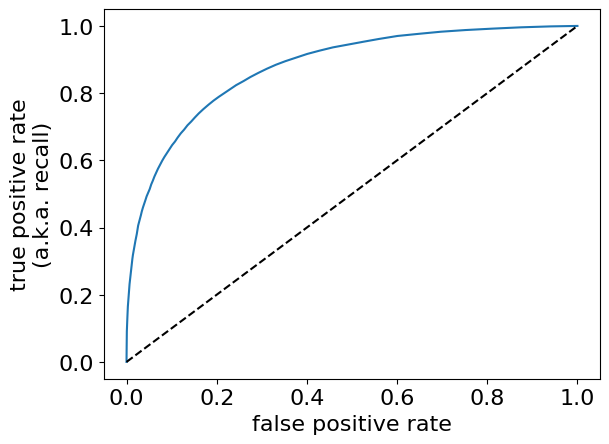

In [43]:
fpr, tpr, thresholds = roc_curve(y_valid, rf.predict_proba(X_valid_transformed)[:,1], pos_label="Yes")

plt.plot(fpr, tpr);
plt.plot((0,1),(0,1),'--k');
plt.xlabel('false positive rate');
plt.ylabel('true positive rate\n(a.k.a. recall)');

## Q11

On the plot above, draw a circle to mark the point where the probability cutoff threshold is equal to 0.5. Briefly justify your answer. **Maximum 3 sentences.**

i am not quite sure. in the middle where both rates equal to 0.5?

---------------

The following code grabs three classifiers learned above:
  - The `DummyClassifier` called `dc`.
  - The `LogisticRegression` called `lr`.
  - The `RandomForestClassifier` called `rf`.

In [44]:
some_models = [dc, lr, rf] 

Next, I shuffle the list of models so you don't know what order they are in.

In [50]:
np.random.seed(999)
some_models = np.array(some_models, dtype=object)
some_models = np.random.permutation(some_models)

To remind you, here is the training accuracy in each case:

In [51]:
dc.score(X_train_transformed, y_train)

0.7669756149699959

In [52]:
lr.score(X_train_transformed, y_train)

0.8465590691850788

In [53]:
rf.score(X_train_transformed, y_train)

0.9998778458108748

In Lecture 8 we looked at some histograms of the predicted probabilities, split by the true class. The following code creates 3 such histograms for 3 different models, using the training set.

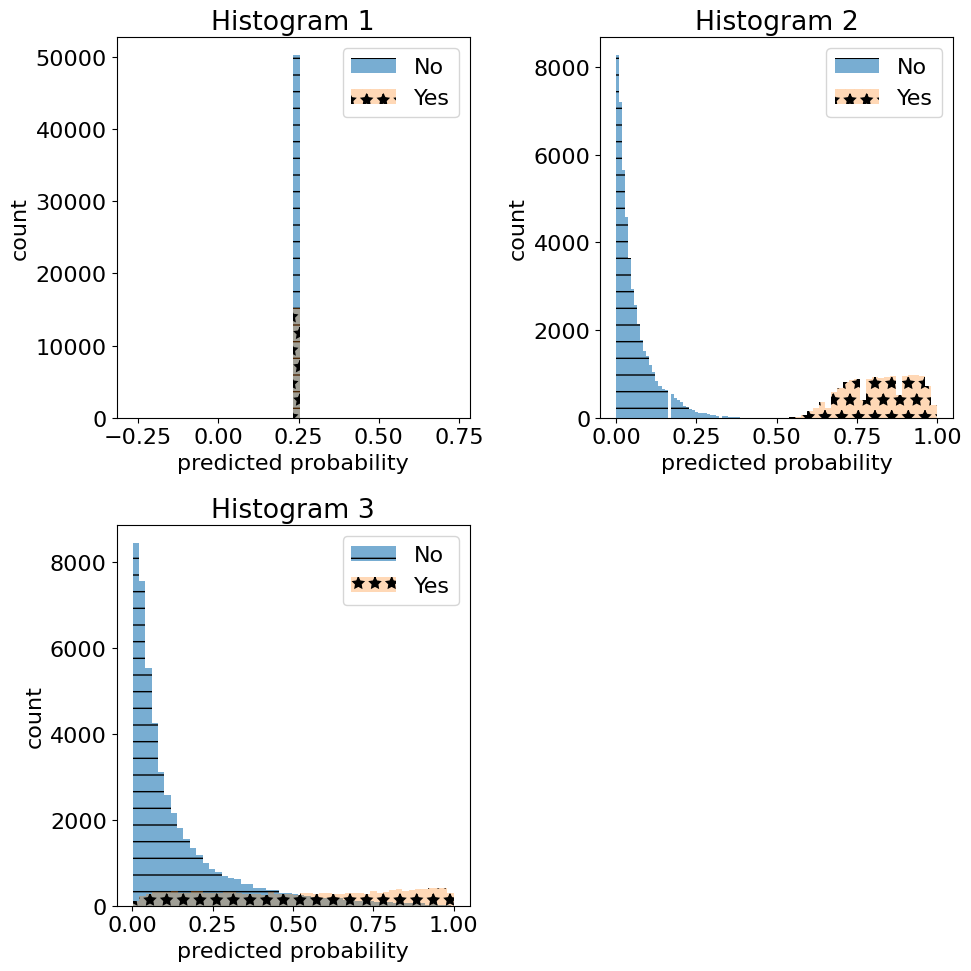

In [54]:
plt.figure(figsize=(10,10))
for i, model in enumerate(some_models):
    plt.subplot(2,2,i+1)
    plt.hist(model.predict_proba(X_train_neg)[:,1], alpha=0.6, bins=50, label="No", hatch="-")
    plt.hist(model.predict_proba(X_train_pos)[:,1], alpha=0.3, bins=50, label="Yes", hatch="*")
    plt.legend(loc='upper right')
    plt.xlabel('predicted probability')
    plt.ylabel("count")
    plt.title(f"Histogram {i+1}")
plt.tight_layout();

## Q12

I haven't told you which model is being used to generate each histogram. Which of the 3 histograms (Histogram 1, Histogram 2, or Histogram 3) do you think corresponds to the **logistic regression** (`lr`) model? Briefly justify your answer. **Maximum 3 sentences.**

The histogram with a blue cliff on the left wall and orange ground. Histogram 2 splits too well (must be the high accuracy random forest), and dummy classifier just predice the probability 0.24 for yes everytime because that is the amt of yes versus nos in the whole dataset, and that is what the straight line bar histogram shows.


---------------

Next, I want to optimize the hyperparameters of my random forest. 

In [55]:
param_grid = {
              "n_estimators"     : [10,100],
              "max_depth"        : [3, 5, 10, 15, None],
              "max_features"     : [3, None]
             }
param_grid

{'n_estimators': [10, 100],
 'max_depth': [3, 5, 10, 15, None],
 'max_features': [3, None]}

In [56]:
grid_search = GridSearchCV(RandomForestClassifier(), 
                           param_grid, cv=5, refit=False,
                           verbose=5, n_jobs=-1)

## Q13

For the grid search above, how many models are trained in total? Briefly justify your answer. **Maximum 2 sentences.**

Note: Don't forget to account for both the different hyperparameter values and the cross-validation folds. Also, I set `refit=False` so you don't have to account for one extra model being trained at the end.

2 * 5 * 2. 20 possible hyperparameter combos, 5 folds for each, so 100 models. (each of the five folds provides a slightly different dataset combo, hence different model even though same hyp param values?)


---------------

At the next point of my analysis, I experience temporary insanity. I do several crazy things:

1. I set all relevant hyperparameters to 3, because 3 is a really cool number.
2. I decide to just optimize `random_state` using `GridSearchCV`, trying all integers from 0 to 999 for the `random_state`.
3. I decide to just use the first 100 training examples for my cross-validation, because I'm too impatient to wait any longer.

In [57]:
grid_search = GridSearchCV(RandomForestClassifier(n_estimators=3, max_depth=3, max_features=3), 
                           {"random_state" : list(range(1000))}, 
                           cv=3, verbose=0, n_jobs=-1)

In [58]:
grid_search.fit(X_train_transformed[:100], y_train[:100]);

Upon doing so, I get a fantastic cross-validation score:

In [61]:
grid_search.best_score_.item()

0.9402852049910874

I will now test out this model on the test set:

In [60]:
grid_search.score(X_test_transformed, y_test)

0.6378301378301379

## Q14

Explain why the test accuracy is so much worse than the cross-validation score. **Maximum 3 sentences.**

1. setting all hyperparameters to 3 is likely not the most optimized. 
2. optimizing random state does not make sense; you are literally telling the program to pick the luckiest score and use that to represent the cross validation accuracy of your model! of course that will set you up for disappointment later on.
3. using just 100 examples for your cross validation means small dataset and luck will play a bigger factor in your overall score.


all this means your cross val score is pretty garbage and is likely way too high and not representative of your actual models ability and your test score will likely be much lower

---------------